In [35]:
# source ../.venv/bin/activate

# trzeba uruchomic jupyter lab z tego juz dzialajacego srodowiska


In [36]:
import os
import matplotlib.pyplot as plt
import numpy as np
import random
import math

def random_seed():
    """
    Zwraca losowy 32-bitowy seed.
    """
    return int(np.random.SeedSequence().entropy)
seed = random_seed()
print(f'seed: {seed}')

seed: 337506901418719366666701430405019510499


Basic form of LF:

$$
\phi(m) = A\,10^{\alpha(m-m_{\rm TRGB})}
$$

where $\alpha$ is around 0.3. 

auxiliary
$10^\alpha = e^\lambda$ and $\lambda = \alpha \cdot ln10$

We draw from 0 to 1 and transform with inverse CDF. $W$ is the range of magnitudes. 

$$
m =
m_{\rm TRGB}
+
\frac{1}{\alpha\ln 10}
\ln\!\left[
1 + u\left(10^{\alpha W}-1\right)
\right]
$$

wspolczynnik przeliczenia ile gwiazd totalnie aby miec np. 100 gwiazd w 100 mag

$$
N_{\rm total} = N_{1mag} \cdot \frac{10^{\alpha W}-1}{10^{\alpha}-1}
$$

In [37]:
def k1mag(alpha=0.3, m_range=5.0):
    """
    Conversion factor between N_1mag and the total number of RGB stars.

    The RGB luminosity function is defined as:

        dN/dm ∝ 10**[alpha * (m - m_trgb)]

    Parameters
    ----------
    alpha : float
        RGB luminosity-function slope. Must be non-negative.
        For alpha = 0, the luminosity function is flat.
    m_range : float
        Magnitude range below the TRGB.

    Returns
    -------
    float
        Ratio N_total / N_1mag.
    """

    if alpha < 0:
        raise ValueError("alpha must be non-negative.")

    if m_range <= 0:
        raise ValueError("m_range must be positive.")

    if alpha == 0:
        return m_range

    lam = alpha * np.log(10.0)

    return (
        (np.exp(lam * m_range) - 1.0)
        / (np.exp(lam) - 1.0)
    )

In [38]:
N1mag = 100
k = k1mag(alpha=0.3,m_range=5.0)
N_tot = int(N1mag * k)

print(f'N1mag: {N1mag}')
print(f'k: {k}')
print(f'Ntot = N1mag * k: {N_tot}')




N1mag: 100
k: 30.768548292357792
Ntot = N1mag * k: 3076


In [39]:
def rgb_lf(m_trgb,alpha=0.3,m_range=5.0,N_stars=None,N_1mag=None,seed=None):
    """
    Generate an RGB luminosity function below the TRGB.

    The luminosity function is defined as:

        dN/dm ∝ 10**[alpha * (m - m_trgb)]

    over the interval:

        m_trgb <= m <= m_trgb + m_range

    Parameters
    ----------
    m_trgb : float
        TRGB magnitude.
    alpha : float
        Luminosity-function slope. Must be non-negative.
        For alpha = 0, the luminosity function is flat.
    m_range : float
        Magnitude range below the TRGB.
    N_stars : int or None
        Exact total number of RGB stars.
    N_1mag : int or None
        Exact number of RGB stars within the first magnitude
        below the TRGB.
    seed : int or None
        Random seed.

    Returns
    -------
    ndarray
        Simulated RGB magnitudes.
    """

    if alpha < 0:
        raise ValueError("alpha must be non-negative.")

    if m_range <= 0:
        raise ValueError("m_range must be positive.")

    if N_stars is None and N_1mag is None:
        raise ValueError("Specify either N_stars or N_1mag.")

    if N_stars is not None and N_1mag is not None:
        raise ValueError("Specify either N_stars or N_1mag, not both.")

    if N_stars is not None and N_stars < 0:
        raise ValueError("N_stars must be non-negative.")

    if N_1mag is not None and N_1mag < 0:
        raise ValueError("N_1mag must be non-negative.")

    if N_1mag is not None and m_range < 1.0:
        raise ValueError(
            "m_range must be at least 1 magnitude "
            "when N_1mag is specified."
        )

    rng = np.random.default_rng(seed)

    # Exact total number of stars
    if N_stars is not None:

        if alpha == 0:
            return rng.uniform(m_trgb,m_trgb + m_range,size=N_stars,)

        lam = alpha * math.log(10.0)
        u = rng.uniform(0.0, 1.0, size=N_stars)

        return m_trgb + (1.0 / lam) * np.log(1.0 + u * (10.0 ** (alpha * m_range) - 1.0))

    # Exact number of stars within the first magnitude
    k = k1mag(alpha=alpha,m_range=m_range,)

    N_tot = round(N_1mag * k)
    N_faint = N_tot - N_1mag

    if alpha == 0:
        m1 = rng.uniform(m_trgb,m_trgb + 1.0,size=N_1mag,)

        m2 = rng.uniform(m_trgb + 1.0,m_trgb + m_range,size=N_faint,)

    else:
        lam = alpha * math.log(10.0)

        u = rng.uniform(0.0, 1.0, size=N_1mag)

        m1 = m_trgb + (1.0 / lam) * np.log(1.0 + u * (10.0 ** alpha - 1.0))

        u = rng.uniform(0.0, 1.0, size=N_faint)

        m2 = m_trgb + 1.0 + (1.0 / lam) * np.log(1.0 + u * (10.0 ** (alpha * (m_range - 1.0)) - 1.0))

    m = np.concatenate((m1, m2))
    rng.shuffle(m)

    return m

N total:  6976
N 1 mag:  1000


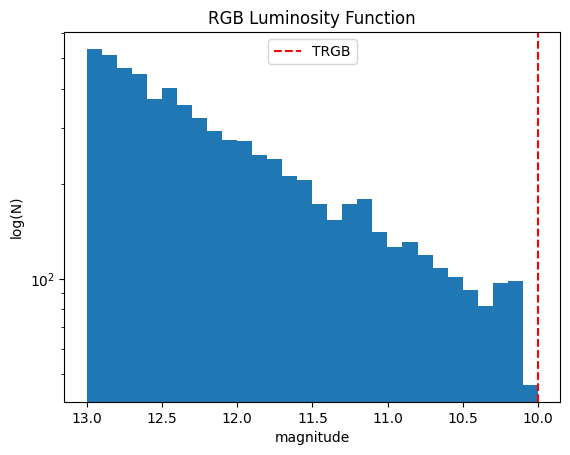

In [40]:
m_trgb = 10
m = rgb_lf(m_trgb, alpha=0.3, m_range=3.0, N_1mag = 1000, seed=seed)
print("N total: ", len(m))
m = np.array(m)
maska = m < 11
m1 = m[maska]
print("N 1 mag: ", len(m1))

plt.figure()

plt.hist(m, bins=30, histtype='bar')
# 'bar', 'barstacked', 'step', 'stepfilled'
plt.axvline(m_trgb, color='red', linestyle='--', label='TRGB')
plt.yscale('log') 
plt.gca().invert_xaxis()
plt.xlabel("magnitude")
plt.ylabel("log(N)")
plt.title("RGB Luminosity Function")
plt.legend()

plt.show()

In [41]:

def k1mag_agb(alpha=0.2, m_range=2.0):
    """
    Conversion factor between N_agb_1mag and the total number
    of AGB stars.

    The AGB luminosity function is defined as:

        dN/dm ∝ 10**[alpha * (m - m_trgb)]

    above the TRGB.

    Parameters
    ----------
    alpha : float
        AGB luminosity-function slope. Must be non-negative.
        For alpha = 0, the luminosity function is flat.
    m_range : float
        Magnitude range above the TRGB. Must be at least
        one magnitude.

    Returns
    -------
    float
        Ratio N_total / N_agb_1mag.
    """

    if alpha < 0:
        raise ValueError("alpha must be non-negative.")

    if m_range < 1.0:
        raise ValueError("m_range must be at least 1 magnitude.")

    if alpha == 0:
        return m_range

    lam = alpha * np.log(10.0)

    return ((1.0 - np.exp(-lam * m_range))/ (1.0 - np.exp(-lam)))


def agb_powerlaw_lf(m_trgb,N_agb_1mag,alpha=0.2,m_range=2.0,seed=None,):
    """
    Generate a power-law AGB luminosity function above the TRGB.

    The luminosity function is defined as:

        dN/dm ∝ 10**[alpha * (m - m_trgb)]

    over the interval:

        m_trgb - m_range <= m <= m_trgb

    Parameters
    ----------
    m_trgb : float
        TRGB magnitude.
    N_agb_1mag : int
        Exact number of AGB stars within the first magnitude
        above the TRGB.
    alpha : float
        Luminosity-function slope. Must be non-negative.
        For alpha = 0, the luminosity function is flat.
    m_range : float
        Magnitude range above the TRGB.
    seed : int or None
        Random seed.

    Returns
    -------
    ndarray
        Simulated AGB magnitudes.
    """

    if N_agb_1mag < 0:
        raise ValueError("N_agb_1mag must be non-negative.")

    if alpha < 0:
        raise ValueError("alpha must be non-negative.")

    if m_range < 1.0:
        raise ValueError("m_range must be at least 1 magnitude.")

    rng = np.random.default_rng(seed)

    k = k1mag_agb(alpha=alpha,m_range=m_range,)

    N_tot = round(N_agb_1mag * k)
    N_bright = N_tot - N_agb_1mag

    if alpha == 0:
        m1 = rng.uniform(m_trgb - 1.0,m_trgb,size=N_agb_1mag,)

        m2 = rng.uniform(m_trgb - m_range,m_trgb - 1.0,size=N_bright,)

    else:
        lam = alpha * math.log(10.0)

        u = rng.uniform(0.0,1.0,size=N_agb_1mag,)

        x1 = -(1.0 / lam) * np.log(1.0 - u * (1.0 - 10.0 ** (-alpha)))

        m1 = m_trgb - x1

        u = rng.uniform(0.0,1.0,size=N_bright,)

        x2 = 1.0 - (1.0 / lam) * np.log(1.0 - u * (1.0 - 10.0 ** (-alpha * (m_range - 1.0))))

        m2 = m_trgb - x2

    m = np.concatenate((m1, m2))
    rng.shuffle(m)

    return m

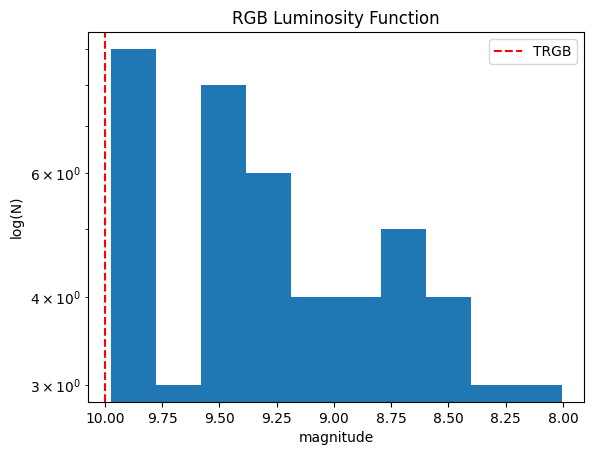

In [42]:
m_agb = agb_powerlaw_lf(m_trgb=10.0,N_agb_1mag=30,alpha=0.2,m_range=2.0,seed=seed)


plt.figure()

plt.hist(m_agb, bins=10, histtype='bar')
# 'bar', 'barstacked', 'step', 'stepfilled'
plt.axvline(m_trgb, color='red', linestyle='--', label='TRGB')
plt.yscale('log') 
plt.gca().invert_xaxis()
plt.xlabel("magnitude")
plt.ylabel("log(N)")
plt.title("RGB Luminosity Function")
plt.legend()

plt.show()

In [43]:


# ------------------------------------------------------------
# Magnitude ↔ flux
# ------------------------------------------------------------

def mag_to_flux(m):
    """
    Convert magnitude to relative flux.
    """
    return 10.0 ** (-0.4 * np.asarray(m))


def flux_to_mag(f):
    """
    Convert relative flux to magnitude.
    """
    f = np.asarray(f)

    if np.any(f <= 0):
        raise ValueError("Flux must be positive.")

    return -2.5 * np.log10(f)


# ------------------------------------------------------------
# Random blending
# ------------------------------------------------------------

def build_blended_catalog(mags, p_pair=0.1, seed=None):
    """
    Generate a separate catalog of blended objects.

    Parameters
    ----------
    mags : array_like
        Input stellar magnitudes.
    p_pair : float
        Fraction of stars selected as primary components.
    seed : int or None
        Random seed.

    Returns
    -------
    blended_mags : ndarray
        Magnitudes of blended objects.
    parent_idx : ndarray
        Indices of first components.
    companion_idx : ndarray
        Indices of secondary components.
    """

    mags = np.asarray(mags, dtype=float)

    if mags.ndim != 1:
        raise ValueError("mags must be one-dimensional.")

    if not 0.0 <= p_pair <= 1.0:
        raise ValueError("p_pair must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    n_blend = round(p_pair * len(mags))

    parent_idx = rng.choice(len(mags),size=n_blend,replace=False,)

    companion_idx = rng.integers(0,len(mags),size=n_blend,)

    same = companion_idx == parent_idx

    while np.any(same):
        companion_idx[same] = rng.integers(0,len(mags),size=np.sum(same),)
        same = companion_idx == parent_idx

    flux_prim = mag_to_flux(mags[parent_idx])
    flux_sec = mag_to_flux(mags[companion_idx])

    blended_mags = flux_to_mag(flux_prim + flux_sec)

    return blended_mags, parent_idx, companion_idx


In [52]:
blended_mags, parent_idx, companion_idx = build_blended_catalog(m,p_pair=0.1,seed=seed,)

mb = m.copy()
mb[parent_idx] = blended_mags

print(f'nadjasnienie: {10-min(mb)}')

mb = np.array(mb)
mk = mb < 10
print(f'liczba zblendowanych gwiazd: {len(mb[mk])}')


nadjasnienie: 0.700859211744957
liczba zblendowanych gwiazd: 38


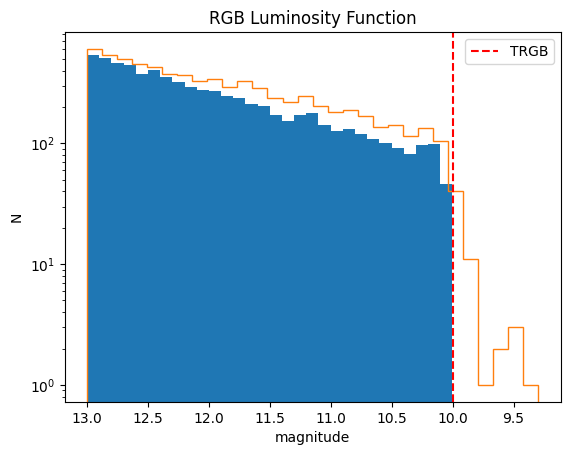

In [53]:
plt.figure()

plt.hist(m, bins=30, histtype='bar')
plt.hist(mb, bins=30, histtype='step')
# 'bar', 'barstacked', 'step', 'stepfilled'

plt.axvline(m_trgb, color='red', linestyle='--', label='TRGB')


plt.yscale('log') 

plt.gca().invert_xaxis()
plt.xlabel("magnitude")
plt.ylabel("N")
plt.title("RGB Luminosity Function")
plt.legend()

plt.show()

In [54]:
# dodanie agb do rgb

m_rgb = mb
m_agb = m_agb

m = np.concatenate((m_rgb,m_agb))


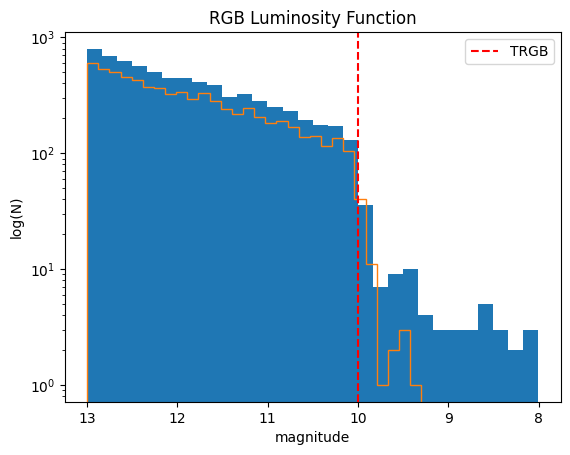

In [55]:
plt.figure()

plt.hist(m, bins=30, histtype='bar')
plt.hist(mb, bins=30, histtype='step')
# 'bar', 'barstacked', 'step', 'stepfilled'
plt.axvline(m_trgb, color='red', linestyle='--', label='TRGB')
plt.yscale('log') 
plt.gca().invert_xaxis()
plt.xlabel("magnitude")
plt.ylabel("log(N)")
plt.title("RGB Luminosity Function")
plt.legend()

plt.show()

In [57]:
def add_photometric_errors(mags, errors, seed=None):
    """
    Perturb magnitudes with Gaussian photometric errors.

    Parameters
    ----------
    mags : array_like
        Input magnitudes.
    errors : float or array_like
        Photometric uncertainties in magnitudes.
        Can be a single value or one value per star.
    seed : int or None
        Random seed.

    Returns
    -------
    ndarray
        Perturbed magnitudes.
    """

    mags = np.asarray(mags, dtype=float)
    errors = np.asarray(errors, dtype=float)

    if mags.ndim != 1:
        raise ValueError("mags must be one-dimensional.")

    if np.any(errors < 0):
        raise ValueError("errors must be non-negative.")

    if errors.ndim > 1:
        raise ValueError("errors must be a scalar or one-dimensional.")

    if errors.ndim == 1 and len(errors) != len(mags):
        raise ValueError("If errors is an array, it must have the same length as mags.")

    rng = np.random.default_rng(seed)

    noise = rng.normal(loc=0.0,scale=errors,size=len(mags),)

    return mags + noise

In [64]:
m_obs = add_photometric_errors(m,errors=0.03,seed=seed,)

# m_err = np.full(len(m), 0.03)
# m_obs = add_photometric_errors(m,errors=m_err,seed=seed,)


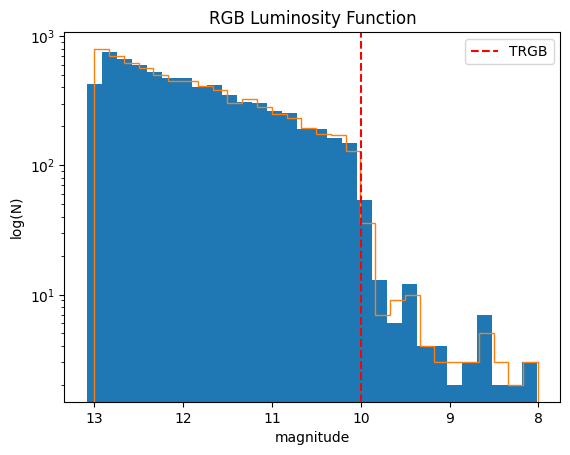

In [65]:
plt.figure()

plt.hist(m_obs, bins=30, histtype='bar')
plt.hist(m, bins=30, histtype='step')
# 'bar', 'barstacked', 'step', 'stepfilled'
plt.axvline(m_trgb, color='red', linestyle='--', label='TRGB')
plt.yscale('log') 
plt.gca().invert_xaxis()
plt.xlabel("magnitude")
plt.ylabel("log(N)")
plt.title("RGB Luminosity Function")
plt.legend()

plt.show()

In [66]:
def completeness_function(mags, m50, width):
    """
    Calculate detection completeness as a function of magnitude.

    The completeness model is:

        C(m) = 1 / (1 + exp((m - m50) / width))

    Parameters
    ----------
    mags : array_like
        Stellar magnitudes.
    m50 : float
        Magnitude at which completeness is 50%.
    width : float
        Width of the completeness transition.
        Smaller values produce a sharper cutoff.

    Returns
    -------
    ndarray
        Detection probabilities between 0 and 1.
    """

    mags = np.asarray(mags, dtype=float)

    if width <= 0:
        raise ValueError("width must be positive.")

    return 1.0 / (
        1.0 + np.exp((mags - m50) / width)
    )


def apply_completeness(mags, m50, width, seed=None):
    """
    Randomly remove stars according to a completeness function.

    Parameters
    ----------
    mags : array_like
        Input magnitudes.
    m50 : float
        Magnitude at which completeness is 50%.
    width : float
        Width of the completeness transition.
    seed : int or None
        Random seed.

    Returns
    -------
    detected_mags : ndarray
        Magnitudes of detected stars.
    detected_idx : ndarray
        Indices of detected stars in the input catalog.
    completeness : ndarray
        Detection probability assigned to each input star.
    """

    mags = np.asarray(mags, dtype=float)

    if mags.ndim != 1:
        raise ValueError("mags must be one-dimensional.")

    completeness = completeness_function(
        mags,
        m50=m50,
        width=width,
    )

    rng = np.random.default_rng(seed)

    detected = rng.random(len(mags)) < completeness
    detected_idx = np.flatnonzero(detected)

    detected_mags = mags[detected_idx]

    return detected_mags, detected_idx, completeness

In [67]:
m_detected, detected_idx, completeness = apply_completeness(m_obs,m50=12.0,width=0.2,seed=seed,)

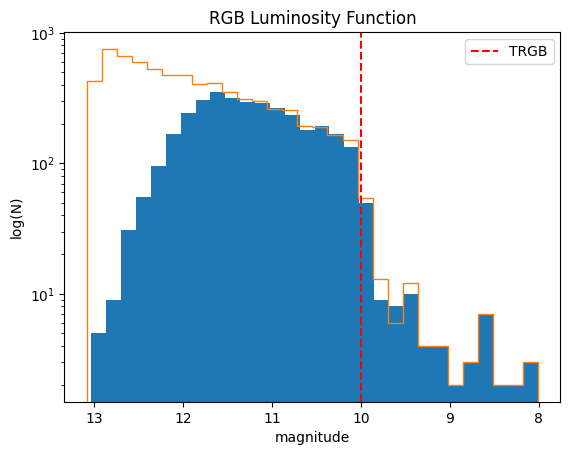

In [68]:
plt.figure()

plt.hist(m_detected, bins=30, histtype='bar')
plt.hist(m_obs, bins=30, histtype='step')
# 'bar', 'barstacked', 'step', 'stepfilled'
plt.axvline(m_trgb, color='red', linestyle='--', label='TRGB')
plt.yscale('log') 
plt.gca().invert_xaxis()
plt.xlabel("magnitude")
plt.ylabel("log(N)")
plt.title("RGB Luminosity Function")
plt.legend()

plt.show()